# Single closed loop inference for freeflyer

In [1]:
import os
import sys
from pathlib import Path
root_folder = Path.cwd().parent

# Add to sys.path
sys.path.append(str(root_folder))

import time
import numpy as np
import numpy.linalg as la
import itertools
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from matplotlib.lines import Line2D

import itertools
from multiprocessing import Pool, set_start_method
from tqdm import tqdm

# /src/
import optimization.ff_scenario as ff
import decision_transformer.manage as DT_manager
from dynamics.freeflyer import FreeflyerModel, ocp_no_obstacle_avoidance, ocp_obstacle_avoidance, ocp_obstacle_avoidance_feasibility, compute_constraint_to_go, sample_init_target
from optimization.ff_scenario import n_time_rpod, N_STATE, N_ACTION, obs, iter_max_SCP, robot_radius, safety_margin, table
from decision_transformer.adapter import FrozenTextAdapter
from dataset_generation.dataset_pargen import load_behavior_texts, get_behavior_text_batch, get_behavior_text, build_waypoint_for_obstacle, pick_terminal_index_and_wp_tidx, sample_case 

device = DT_manager.device
print(f"Using device: {device}")
set_start_method('spawn')

/home/arpit/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
model_version_ctg = 'v_06' # v_03 for SCP+CVX IL with ctg, trained on less data v_06
model_version_text = 'v_04' # v_04 for SCP IL
dataset_version = 'v01'

import_config = DT_manager.transformer_import_config(model_version_ctg)
ctg_condition = import_config["ctg_condition"]
timestep_norm = import_config["timestep_norm"]
dataset_to_use = import_config["dataset_to_use"] 


# Get the datasets and loaders from the torch data
datasets, dataloaders = DT_manager.get_train_val_test_data( ctg_condition=ctg_condition, timestep_norm=timestep_norm, dataset_to_use=dataset_to_use, dataset_version=dataset_version, max_samples = 80000)
train_loader, eval_loader, test_loader = dataloaders

# Get both ART models
model_ctg = DT_manager.get_DT_model(model_version_ctg, train_loader, eval_loader, ctg_condition = True)
model_text = DT_manager.get_DT_model(model_version_text, train_loader, eval_loader, ctg_condition = False)

# load the text encoders for each models (and its weight)  
MODEL = os.getenv("FTA_MODEL", "distilbert-base-uncased")
text_encoder_ctg = FrozenTextAdapter(model_name=MODEL, out_dim=model_ctg.hidden_size, output_mode="tokens").to(device).eval()
text_encoder_ctg.load_adapter(root_folder / "decision_transformer" / "saved_files" / "checkpoints" / f"{model_version_ctg}" / "text_adapter.pth") 

text_encoder_text = FrozenTextAdapter(model_name=MODEL, out_dim=model_text.hidden_size, output_mode="tokens").to(device).eval()
text_encoder_text.load_adapter(root_folder / "decision_transformer" / "saved_files" / "checkpoints" / f"{model_version_text}" / "text_adapter.pth") 


Data is loaded but not shuffled yet!

Data shuffled and combined from both SCP and CVX datasets.

torch.Size([80000, 100, 6])
GPT size: 11.1M parameters
GPT size: 11.1M parameters


/home/arpit/miniforge3/envs/ART/lib/python3.10/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


# Helper Func

In [3]:
# FreeFlyerModel
ff_model = FreeflyerModel()
def _plot_environment(ax):
    # Table
    ax.add_patch(
        Rectangle(
            (table['xy_low'][0], table['xy_low'][1]),
            table['xy_up'][0] - table['xy_low'][0],
            table['xy_up'][1] - table['xy_low'][1],
            fc=(0.5, 0.5, 0.5, 0.15),
            ec='k',
            # label='table',
            label=None,
            zorder=2.5,
        )
    )

    # Obstacles + inflated robot radius
    for n in range(obs['radius'].shape[0]):
        lab1 = 'Obstacle'
        lab3 = 'L/R Body' if n == 0 else None
        # lab2 = 'robot radius' if n == 0 else None
        lab2 =  None
        if n == 1:
            ax.add_patch(
                Circle(
                    obs['position'][n, :],
                    obs['radius'][n],
                    fc='r',
                    ec='none',
                    label=lab1,
                    zorder=2.6,
                )
            )
            ax.add_patch(
                Circle(
                    obs['position'][n, :],
                    obs['radius'][n] + robot_radius,
                    fc='grey',
                    alpha=0.2,
                    ec='none',
                    label=lab2,
                    zorder=2.6,
                )
            )
        else:
            ax.add_patch(
                Circle(
                    obs['position'][n, :],
                    obs['radius'][n],
                    fc='g',
                    ec='none',
                    label=lab3,
                    zorder=2.6,
                )
            )
            ax.add_patch(
                Circle(
                    obs['position'][n, :],
                    obs['radius'][n] + robot_radius,
                    fc='grey',
                    alpha=0.2,
                    ec='none',
                    label=lab2,
                    zorder=2.6,
                )
            )

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(table['xy_low'][0], table['xy_up'][0])
    ax.set_ylim(table['xy_low'][1], table['xy_up'][1])

# pad the traj to always be shape [6,101] and [3, 100]

def pad_traj_to_full(states, actions_G, n_time_rpod):
    """
    states:  (6, k_T+1)
    actions: (3, k_T)
    returns: states (6, n_time_rpod+1), actions (3, n_time_rpod)
    """
    cur_S = states.shape[1]   # k_T+1
    cur_A = actions_G.shape[1]  # k_T
    need_S = (n_time_rpod + 1) - cur_S
    need_A = n_time_rpod - cur_A
    if need_S > 0:
        states = np.hstack([states, np.repeat(states[:, -1][:, None], need_S, axis=1)])
    if need_A > 0:
        actions_G = np.hstack([actions_G, np.zeros((actions_G.shape[0], need_A))])
    return states, actions_G

In [10]:
'''
Test samples to utilize for infernece

Initial Start states:

    0: Random Start states = np.random.uniform(low=[0.15, 0.15, -np.pi, 0, 0, 0], high=[0.35, 2.35, np.pi, 0, 0, 0])
    1: slighlty leftward   =  np.array([0.25, 1.8,  np.pi/12, 0.0, 0.0, 0.0])
    2: slighlty rightward  =  np.array([0.25, 0.5,  np.pi/15, 0.0, 0.0, 0.0])
    3. Around Midpoint     =  np.array([0.20, 1.25, np.pi/30, 0.0, 0.0, 0.0])
    4: slighlty leftward   =  np.array([0.25, 1.8,  -np.pi/12, 0.0, 0.0, 0.0])
    5: slighlty rightward  =  np.array([0.25, 0.5,  -np.pi/15, 0.0, 0.0, 0.0])
    6. Around Midpoint     =  np.array([0.20, 1.25, -np.pi/30, 0.0, 0.0, 0.0])


Final Target State:
    [(ff.goal_region['xy_low'][0] + ff.goal_region['xy_up'][0])/2,
                                  (ff.goal_region['xy_low'][1] + ff.goal_region['xy_up'][1])/2,
                                  0.0,
                                  0.0,
                                  0.0,
                                  0.0]
'''

state_init = np.array([0.25, 0.35,  np.pi/30, 0.0, 0.0, 0.0]) # [0.25, 1.35,  np.pi/12, 0.0, 0.0, 0.0] right fast

state_final = np.array([(ff.goal_region['xy_low'][0] + ff.goal_region['xy_up'][0])/2,
                                  (ff.goal_region['xy_low'][1] + ff.goal_region['xy_up'][1])/2,
                                  0.0,
                                  0.0,
                                  0.0,
                                  0.0])

### Waypoint sampling and setting the timestamp
behavior_i = 0 #
text_command = "To preserve clearance, a left-bias routing skirts the KOZ and rapid movement."  
# behavior_i = 1 #
# text_command = "Perform a broad left-side arc, expanding clearance for extended standoff with minimal Δv."


current_idx = 99
seed = 7 + current_idx
rng = np.random.default_rng(seed)
command_mapping = load_behavior_texts()
k_T, k_wp = pick_terminal_index_and_wp_tidx(behavior_i, rng)
wp = None
if behavior_i in {0, 1}:
    wp = build_waypoint_for_obstacle(behavior_i)
elif behavior_i in {2, 3}:
    wp = build_waypoint_for_obstacle(behavior_i)
if wp is not None and k_wp is not None:
    wp['t_index'] = int(k_wp)

print('Sampled waypoint position:', wp['pos'])
##################################

test_sample = test_loader.dataset.getix(current_idx)
data_stats = test_loader.dataset.data_stats

(states_i, actions_i, rtgs_i, ctgs_i, goal_i, timesteps_i, attention_mask_i, dt, time_sec, ix, behavior_i_t, command_id_i_t) = test_sample
print(states_i[0, 0, :])
test_sample[0][0,:,:] = (torch.tensor(np.repeat(state_init[None,:], n_time_rpod, axis=0)) - data_stats['states_mean'])/(data_stats['states_std'] + 1e-6)
test_sample[1][0,:,:] = torch.zeros((n_time_rpod, N_ACTION))
test_sample[2][0,:,0] = torch.zeros((n_time_rpod,))
test_sample[3][:,0] = torch.zeros((n_time_rpod,))

# Note in this follwoing packing, we will not use the beavhior and command id, that is just meant to use rtgs_i, ctgs_i, goal_i, timesteps_i, attention_mask_i, dt, time_sec
test_sample = (states_i, actions_i, rtgs_i, ctgs_i, goal_i, timesteps_i, attention_mask_i, dt, time_sec, ix, behavior_i_t, command_id_i_t)
print(test_sample[0][0, 0, :])

Sampled waypoint position: [1.64593844 1.82686438]
tensor([-1.6587e+00, -7.5575e-01, -2.8367e+00, -1.6668e+00, -2.3140e-04,
         1.3510e-04])
tensor([-1.6556e+00, -2.2371e+00,  9.9711e-02, -1.6668e+00, -2.3140e-04,
         1.3510e-04])


# Save the datastats file in dataset/torch/v01/data_state.npz

In [12]:
# save the data_stats for later use
# data_stats_path = root_folder / "dataset" / "torch" / f"{dataset_version}" / f"data_stats.npz"
# np.savez(data_stats_path, data_stats=data_stats)

# Load the inference

In [11]:


runtime0_cvx = time.time()
traj_cvx, _, _, feas_cvx  = ocp_no_obstacle_avoidance(ff_model, state_init, state_final, n_time_override=k_T, waypoint=wp)
# traj_cvx, _, _, feas_cvx  = ocp_no_obstacle_avoidance(ff_model, state_init, state_final, n_time_override=None, waypoint=None)
runtime1_cvx = time.time()
runtime_cvx = runtime1_cvx-runtime0_cvx
states_cvx, actions_cvx = traj_cvx['states'], traj_cvx['actions_G']

print('CVX cost:', np.sum(la.norm(actions_cvx, ord=1, axis=0)))
print('CVX runtime:', runtime_cvx)
states_cvx_full, actions_cvx_full = pad_traj_to_full(states_cvx, actions_cvx, n_time_rpod)

states_ws_cvx = states_cvx # set warm start
actions_ws_cvx = actions_cvx # set warm start
# Evaluate Constraint Violation
ctgs_cvx = compute_constraint_to_go(states_ws_cvx.T, obs['position'], (obs['radius'] + robot_radius)*safety_margin)
ctgs0_cvx = ctgs_cvx[0,0]

# Solve SCP
runtime0_scp_cvx = time.time()
traj_scp_cvx, J_vect_scp_cvx, iter_scp_cvx, feas_scp_cvx = ocp_obstacle_avoidance_feasibility(ff_model, states_ws_cvx, actions_ws_cvx, state_init, state_final, w_tracking=1.0)
runtime1_scp_cvx = time.time()
runtime_scp_cvx = runtime1_scp_cvx - runtime0_scp_cvx

states_scp_full, actions_scp_full = pad_traj_to_full(traj_scp_cvx['states'], traj_scp_cvx['actions_G'], n_time_rpod)
print('SCP cost:', np.sum(la.norm(actions_scp_full, ord=1, axis=0)))
print('SCP runtime:', runtime_scp_cvx, iter_scp_cvx)

CVX cost: 1.1389453890812293
CVX runtime: 7.2973833084106445
SCP cost: 1.2215677831341556
SCP runtime: 2.192209243774414 3


# Transformer Model - text+ctg

In [12]:
DT_ctg_trajectory, runtime_DT_ctg = DT_manager.torch_model_inference_dyn(model_ctg, test_loader, test_sample, text_encoder_ctg, command_mapping, ctg_condition=True, text_command=text_command)
# DT_ctg_trajectory, runtime_DT_ctg = DT_manager.torch_model_inference_dyn(model_ctg, test_loader, test_sample, text_encoder_ctg, command_mapping, ctg_condition=True, text_command=None)
states_ws_DT_ctg = np.append(DT_ctg_trajectory['xypsi_dyn'], (DT_ctg_trajectory['xypsi_dyn'][:,-1] + ff_model.B_imp @ DT_ctg_trajectory['dv_dyn'][:, -1]).reshape((6,1)), 1)# set warm start
actions_ws_DT_ctg = DT_ctg_trajectory['dv_dyn'] # set warm start
print('ART cost:', np.sum(la.norm(actions_ws_DT_ctg, ord=1, axis=0)))
print('ART runtime:', runtime_DT_ctg)

# Evaluate Constraint Violation
ctgs_DT_ctg = compute_constraint_to_go(states_ws_DT_ctg.T, obs['position'], (obs['radius'] + robot_radius)*safety_margin)
ctgs0_DT_ctg = ctgs_DT_ctg[0,0]

# Solve SCP
runtime0_scp_DT_ctg = time.time()
traj_scp_DT_ctg, J_vect_scp_DT_ctg, iter_scp_DT_ctg, feas_scp_DT_ctg = ocp_obstacle_avoidance_feasibility(ff_model, states_ws_DT_ctg, actions_ws_DT_ctg, state_init, state_final)
runtime1_scp_DT_ctg = time.time()
runtime_scp_DT_ctg = runtime1_scp_DT_ctg - runtime0_scp_DT_ctg  

states_scp_DT_ctg = traj_scp_DT_ctg['states']
actions_scp_DT_ctg = traj_scp_DT_ctg['actions_G'] 

print('SCP cost:', np.sum(la.norm(actions_scp_DT_ctg, ord=1, axis=0)))
print('SCP time and iter:',runtime_scp_DT_ctg ,iter_scp_DT_ctg)

# Evaluate Constraint Violation
ctgs_DT_scp_ctg = compute_constraint_to_go(states_scp_DT_ctg.T, obs['position'], (obs['radius'] + robot_radius)*safety_margin)
ctgs0_DT_scp_ctg = ctgs_DT_scp_ctg[0,0]


ART cost: 1.1971909
ART runtime: 0.33072423934936523
SCP cost: 1.1623851525657474
SCP time and iter: 2.285351276397705 2


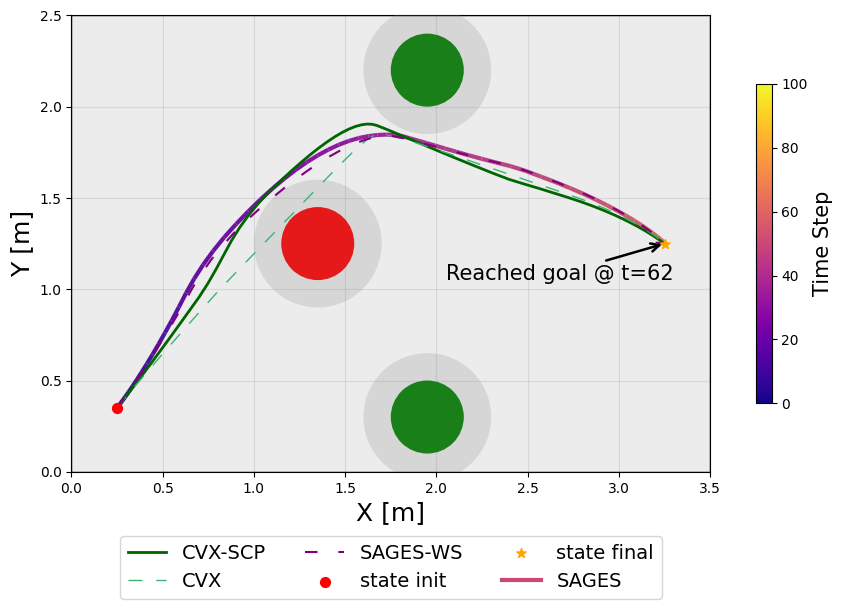

In [13]:

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

def plot_time_colored_line(ax, xs, ys, cmap='plasma', label=None):

    points = np.array([xs, ys]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    lc = LineCollection(segments, cmap=cmap)
    lc.set_array(np.arange(len(xs)))   # color = time index
    lc.set_linewidth(3.0)
    
    ax.add_collection(lc)
    return lc

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot()
_plot_environment(ax)

mid_color = plt.get_cmap('plasma')(0.5)   # 0.5 = midpoint of colormap
sages_handle = Line2D(
    [0], [0],
    color=mid_color,
    linewidth=3,
    label='SAGES'
)

ax.plot(
    states_scp_full[0, :], states_scp_full[1, :],
    linestyle='-', color='darkgreen', linewidth=2.0,
    label='CVX-SCP', zorder=4
)

ax.plot(
    states_ws_cvx[0, :], states_ws_cvx[1, :],
    linestyle=(0, (10, 10)), color='mediumseagreen', linewidth=1.,
    label='CVX', zorder=4
)

ax.plot(
    states_ws_DT_ctg[0, :], states_ws_DT_ctg[1, :],
    linestyle=(0, (6, 10)), color='purple', linewidth=1.5,
    label='SAGES-WS', zorder=4
)


# Example usage:
# Time-colored SCP trajectory
lc = plot_time_colored_line(
    ax,
    states_scp_DT_ctg[0,:],
    states_scp_DT_ctg[1,:],
)
cb = fig.colorbar(lc, ax=ax, shrink=0.7)
cb.set_label("Time Step", fontsize = 15)

# Annotate goal reach time
t_goal = np.argmax(np.sqrt((states_scp_DT_ctg[0,:]-state_final[0])**2 +
                           (states_scp_DT_ctg[1,:]-state_final[1])**2) < 0.04)
offset = np.array([-1.2, -0.2])   # tune depending on scale
gx, gy = state_final[0], state_final[1]
ax.annotate(f"Reached goal @ t={t_goal}",
            xy=(gx, gy),                      # point to
            xytext=(gx + offset[0], gy + offset[1]), # text location
            fontsize=15,
            arrowprops=dict(arrowstyle="->", lw=1.8))

ax.scatter(state_init[0], state_init[1], s=50, marker='o', c='red', label='state init', zorder=5)
ax.scatter(state_final[0], state_final[1], s=50, marker='*', c='orange', label='state final', zorder=5)


# Formatting
ax.set_aspect('equal')
ax.set_xlabel('X [m]', fontsize=18)
ax.set_ylabel('Y [m]', fontsize=18)
ax.grid(True, alpha=0.3)
handles, labels = ax.get_legend_handles_labels()
handles.append(sages_handle)
labels.append('SAGES')

ax.legend(loc='best', fontsize=18)
ax.legend(handles, labels,
           loc='lower center',
           ncol=len(labels)//2,
           bbox_to_anchor=(0.5, -0.30),
           fontsize=14)
plt.tight_layout()
plt.show()


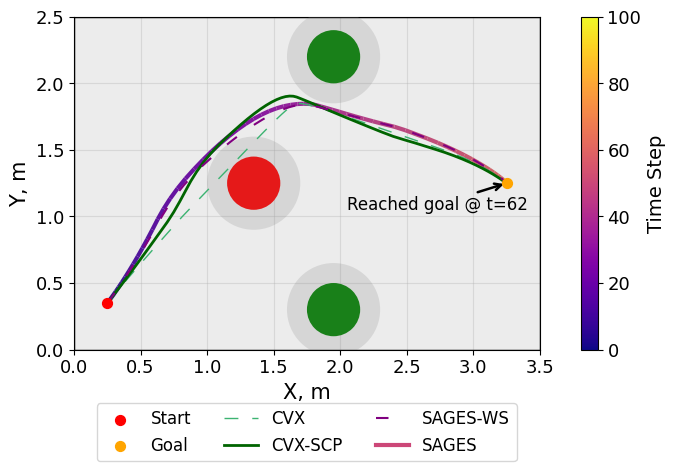

In [14]:
def _plot_environment(ax):
    # Table
    ax.add_patch(
        Rectangle(
            (table['xy_low'][0], table['xy_low'][1]),
            table['xy_up'][0] - table['xy_low'][0],
            table['xy_up'][1] - table['xy_low'][1],
            fc=(0.5, 0.5, 0.5, 0.15),
            ec='k',
            label='',
            zorder=2.5,
        )
    )

    # Obstacles + inflated robot radius
    for n in range(obs['radius'].shape[0]):
        lab1 = ''
        lab3 = '' if n == 0 else None
        lab2 = '' if n == 0 else None
        if n == 1:
            ax.add_patch(
                Circle(
                    obs['position'][n, :],
                    obs['radius'][n],
                    fc='r',
                    ec='none',
                    label=lab1,
                    zorder=2.6,
                )
            )
            ax.add_patch(
                Circle(
                    obs['position'][n, :],
                    obs['radius'][n] + robot_radius,
                    fc='grey',
                    alpha=0.2,
                    ec='none',
                    label=lab2,
                    zorder=2.6,
                )
            )
        else:
            ax.add_patch(
                Circle(
                    obs['position'][n, :],
                    obs['radius'][n],
                    fc='g',
                    ec='none',
                    label=lab3,
                    zorder=2.6,
                )
            )
            ax.add_patch(
                Circle(
                    obs['position'][n, :],
                    obs['radius'][n] + robot_radius,
                    fc='grey',
                    alpha=0.2,
                    ec='none',
                    label=lab2,
                    zorder=2.6,
                )
            )

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('X, m')
    # ax.set_ylabel('Y, m')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(table['xy_low'][0], table['xy_up'][0])
    ax.set_ylim(table['xy_low'][1], table['xy_up'][1])

def plot_time_colored_line(ax, xs, ys, cmap='plasma', label=None):

    points = np.array([xs, ys]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    lc = LineCollection(segments, cmap=cmap)
    lc.set_array(np.arange(len(xs)))   # color = time index
    lc.set_linewidth(3.0)
    
    ax.add_collection(lc)
    return lc

fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot()
_plot_environment(ax)
ax.scatter(state_init[0], state_init[1], s=50, marker='o', c='red', label='Start', zorder=5)
ax.scatter(state_final[0], state_final[1], s=50, marker='o', c='orange', label='Goal', zorder=5)

ax.plot(
    states_ws_cvx[0, :], states_ws_cvx[1, :],
    linestyle=(0, (10, 10)), color='mediumseagreen', linewidth=1.,
    label='CVX', zorder=4
)

ax.plot(
    states_scp_full[0, :], states_scp_full[1, :],
    linestyle='-', color='darkgreen', linewidth=2.0,
    label='CVX-SCP', zorder=4
)

ax.plot(
    states_ws_DT_ctg[0, :], states_ws_DT_ctg[1, :],
    linestyle=(0, (6, 10)), color='purple', linewidth=1.5,
    label='SAGES-WS', zorder=4
)

mid_color = plt.get_cmap('plasma')(0.5)   # 0.5 = midpoint of colormap
sages_handle = Line2D(
    [0], [0],
    color=mid_color,
    linewidth=3,
    label='SAGES'
)

# Example usage:
# Time-colored SCP trajectory
lc = plot_time_colored_line(
    ax,
    states_scp_DT_ctg[0,:],
    states_scp_DT_ctg[1,:],
)
cb = fig.colorbar(lc, ax=ax, shrink=1)
cb.set_label("Time Step", fontsize = 14)
cb.ax.tick_params(labelsize=13)

# Annotate goal reach time
t_goal = np.argmax(np.sqrt((states_scp_DT_ctg[0,:]-state_final[0])**2 +
                           (states_scp_DT_ctg[1,:]-state_final[1])**2) < 0.04)
offset = np.array([-1.2, -0.2])   # tune depending on scale
gx, gy = state_final[0], state_final[1]
ax.annotate(f"Reached goal @ t={t_goal}",
            xy=(gx, gy),                      # point to
            xytext=(gx + offset[0], gy + offset[1]), # text location
            fontsize=12,
            arrowprops=dict(arrowstyle="->", lw=1.8))

ax.tick_params(axis='both', labelsize=13)

# Formatting
ax.set_aspect('equal')
ax.set_xlabel('X, m', fontsize=15)
ax.set_ylabel('Y, m', fontsize=15)
ax.grid(True, alpha=0.3)
handles, labels = ax.get_legend_handles_labels()
handles.append(sages_handle)
labels.append('SAGES')

ax.legend(loc='best', fontsize=15)
ax.legend(handles, labels,
           loc='lower center',
           ncol=len(labels)//2,
           bbox_to_anchor=(0.5, -0.36),
           fontsize=12)
plt.tight_layout()
plt.show()
fig.savefig("ff_banger_soln2.png", dpi=600, bbox_inches='tight')

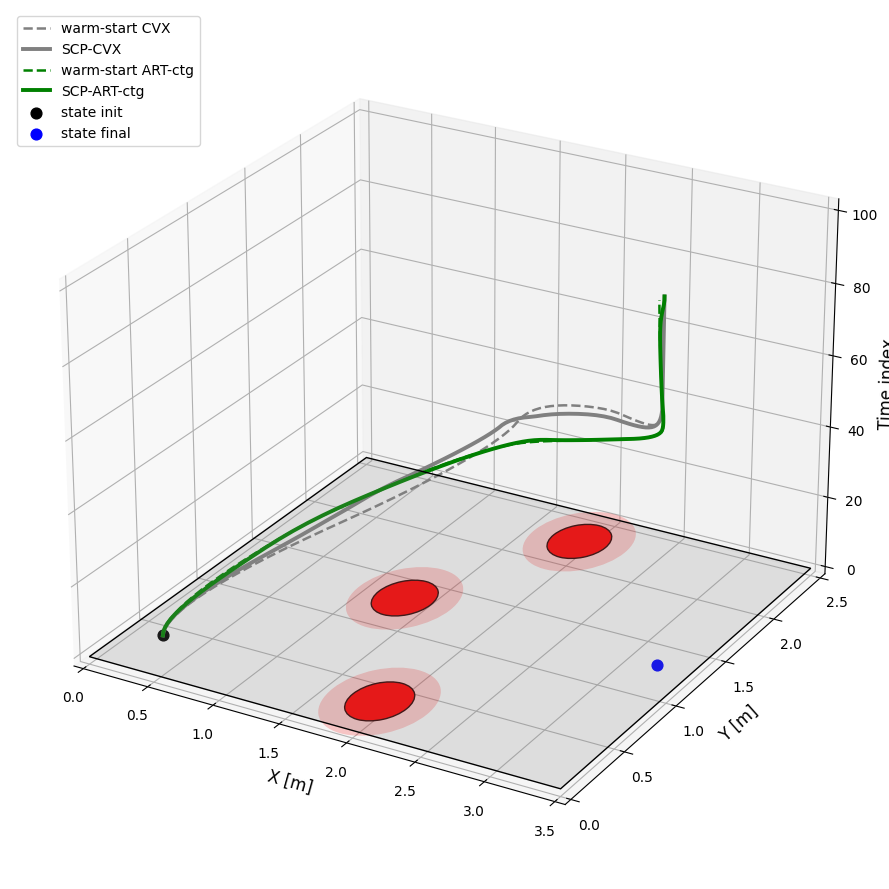

In [8]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Circle
from mpl_toolkits.mplot3d import art3d

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

# --- time axes for each trajectory ---
T_ws_cvx   = states_ws_cvx.shape[1]
T_scp_cvx  = states_scp_full.shape[1]
T_ws_ctg   = states_ws_DT_ctg.shape[1]
T_scp_ctg  = states_scp_DT_ctg.shape[1]

t_ws_cvx   = np.arange(T_ws_cvx)
t_scp_cvx  = np.arange(T_scp_cvx)
t_ws_ctg   = np.arange(T_ws_ctg)
t_scp_ctg  = np.arange(T_scp_ctg)

# ------------------------------
#   TRAJECTORIES (3D)
# ------------------------------

# CVX warm-start (dashed grey)
ax.plot(
    states_ws_cvx[0, :], states_ws_cvx[1, :], t_ws_cvx,
    linestyle='--', color='grey', linewidth=1.8,
    label='warm-start CVX', zorder=5
)

# CVX SCP (solid grey)
ax.plot(
    states_scp_full[0, :], states_scp_full[1, :], t_scp_cvx,
    linestyle='-', color='grey', linewidth=2.8,
    label='SCP-CVX', zorder=6
)

# ART warm-start (dashed green)
ax.plot(
    states_ws_DT_ctg[0, :], states_ws_DT_ctg[1, :], t_ws_ctg,
    linestyle='--', color='green', linewidth=1.8,
    label='warm-start ART-ctg', zorder=7
)

# ART SCP (solid green)
ax.plot(
    states_scp_DT_ctg[0, :], states_scp_DT_ctg[1, :], t_scp_ctg,
    linestyle='-', color='green', linewidth=2.8,
    label='SCP-ART-ctg', zorder=8
)

# ------------------------------
#   ENVIRONMENT (projected at t=0)
# ------------------------------

# Table as a 2D patch projected into 3D at z=0
table_patch = Rectangle(
    (0, 0),
    table['xy_up'][0], table['xy_up'][1],
    fc=(0.5, 0.5, 0.5, 0.2), ec='k'
)
ax.add_patch(table_patch)
art3d.pathpatch_2d_to_3d(table_patch, z=0, zdir="z")

# Obstacles (also projected at z=0)
for n_obs in range(obs['radius'].shape[0]):
    circle_main = Circle(obs['position'][n_obs], obs['radius'][n_obs], fc='r', ec='k')
    ax.add_patch(circle_main)
    art3d.pathpatch_2d_to_3d(circle_main, z=0, zdir="z")

    circle_inf = Circle(
        obs['position'][n_obs], obs['radius'][n_obs] + robot_radius,
        fc='r', alpha=0.2
    )
    ax.add_patch(circle_inf)
    art3d.pathpatch_2d_to_3d(circle_inf, z=0, zdir="z")

# ------------------------------
# START + GOAL (put them at t=0)
# ------------------------------
ax.scatter(state_init[0], state_init[1], 0, s=60, c='black', label='state init', zorder=10)
ax.scatter(state_final[0], state_final[1], 0, s=60, c='blue',  label='state final', zorder=10)

# ------------------------------
# Formatting
# ------------------------------

ax.set_xlabel('X [m]', fontsize=12)
ax.set_ylabel('Y [m]', fontsize=12)
ax.set_zlabel('Time index', fontsize=12)

ax.set_xlim(0, table['xy_up'][0])
ax.set_ylim(0, table['xy_up'][1])

T_max = max(T_ws_cvx, T_scp_cvx, T_ws_ctg, T_scp_ctg)
ax.set_zlim(0, T_max)

ax.view_init(elev=25, azim=-60)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()


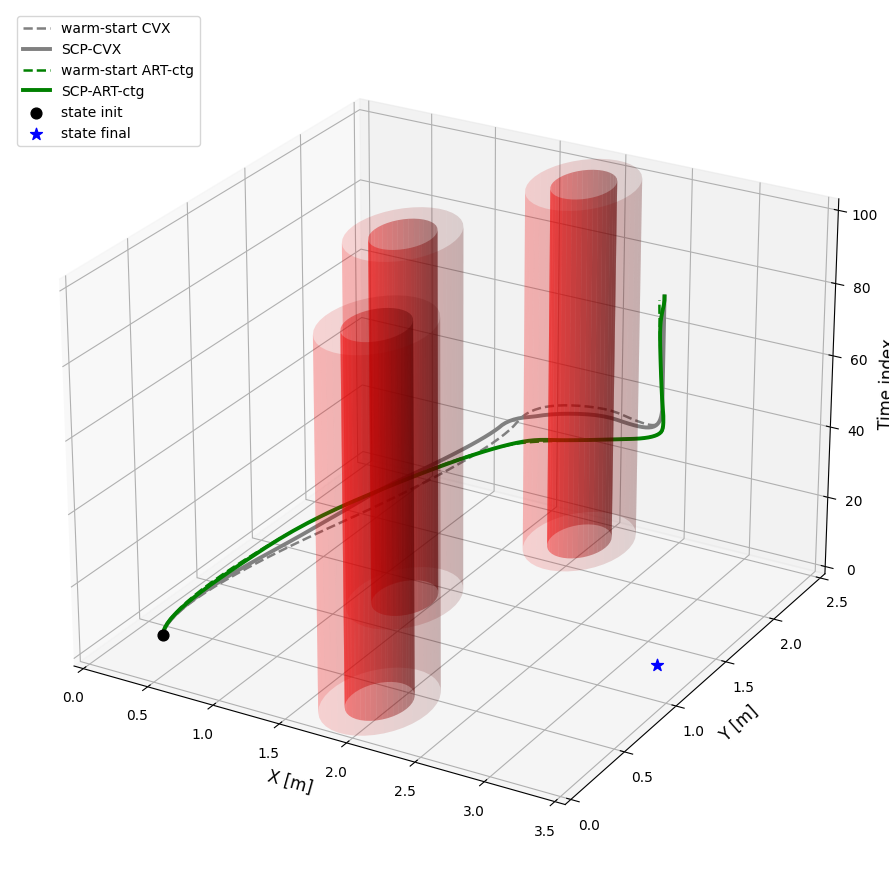

In [9]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------
# Time vectors
# ------------------------------
T_ws_cvx   = states_ws_cvx.shape[1]
T_scp_cvx  = states_scp_full.shape[1]
T_ws_ctg   = states_ws_DT_ctg.shape[1]
T_scp_ctg  = states_scp_DT_ctg.shape[1]

t_ws_cvx   = np.arange(T_ws_cvx)
t_scp_cvx  = np.arange(T_scp_cvx)
t_ws_ctg   = np.arange(T_ws_ctg)
t_scp_ctg  = np.arange(T_scp_ctg)

T_max = max(T_ws_cvx, T_scp_cvx, T_ws_ctg, T_scp_ctg)

# Helper: extract X,Y
def xy(state):
    return state[0, :], state[1, :]

x_ws_cvx,  y_ws_cvx  = xy(states_ws_cvx)
x_scp_cvx, y_scp_cvx = xy(states_scp_full)
x_ws_ctg,  y_ws_ctg  = xy(states_ws_DT_ctg)
x_scp_ctg, y_scp_ctg = xy(states_scp_DT_ctg)

# ------------------------------
# Build Figure
# ------------------------------
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

# ------------------------------
# Trajectories in (X, Y, Time)
# X-axis = X-position
# Y-axis = Y-position
# Z-axis = Time index
# ------------------------------

# CVX warm-start
ax.plot(
    x_ws_cvx, y_ws_cvx, t_ws_cvx,
    '--', color='grey', linewidth=1.8,
    label='warm-start CVX'
)

# CVX SCP
ax.plot(
    x_scp_cvx, y_scp_cvx, t_scp_cvx,
    '-', color='grey', linewidth=2.8,
    label='SCP-CVX'
)

# ART warm-start
ax.plot(
    x_ws_ctg, y_ws_ctg, t_ws_ctg,
    '--', color='green', linewidth=1.8,
    label='warm-start ART-ctg'
)

# ART SCP
ax.plot(
    x_scp_ctg, y_scp_ctg, t_scp_ctg,
    '-', color='green', linewidth=2.8,
    label='SCP-ART-ctg'
)

# ------------------------------
# Obstacles as cylinders (extruded along Z=time)
# ------------------------------
n_theta = 40
n_t = 2

theta = np.linspace(0, 2*np.pi, n_theta)
tau   = np.linspace(0, T_max, n_t)
Theta, Tau = np.meshgrid(theta, tau)

for i in range(obs['radius'].shape[0]):
    x0, y0 = obs['position'][i]
    r_main = obs['radius'][i]
    r_inf  = obs['radius'][i] + robot_radius

    # main obstacle cylinder
    X_main = x0 + r_main * np.cos(Theta)
    Y_main = y0 + r_main * np.sin(Theta)
    Z_main = Tau

    ax.plot_surface(
        X_main, Y_main, Z_main,
        color='red', alpha=0.40, linewidth=0
    )

    # inflated (robot radius safety) cylinder
    X_inf = x0 + r_inf * np.cos(Theta)
    Y_inf = y0 + r_inf * np.sin(Theta)
    Z_inf = Tau

    ax.plot_surface(
        X_inf, Y_inf, Z_inf,
        color='red', alpha=0.15, linewidth=0
    )

# ------------------------------
# Start & Goal at time=0
# ------------------------------
ax.scatter(
    state_init[0], state_init[1], 0,
    s=60, c='black', label='state init'
)
ax.scatter(
    state_final[0], state_final[1], 0,
    s=80, c='blue', marker='*', label='state final'
)

# ------------------------------
# Axes Formatting
# ------------------------------
ax.set_xlabel("X [m]", fontsize=12)
ax.set_ylabel("Y [m]", fontsize=12)
ax.set_zlabel("Time index", fontsize=12)

ax.set_xlim(0, table['xy_up'][0])
ax.set_ylim(0, table['xy_up'][1])
ax.set_zlim(0, T_max)

# Camera angle
ax.view_init(elev=25, azim=-60)

ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()


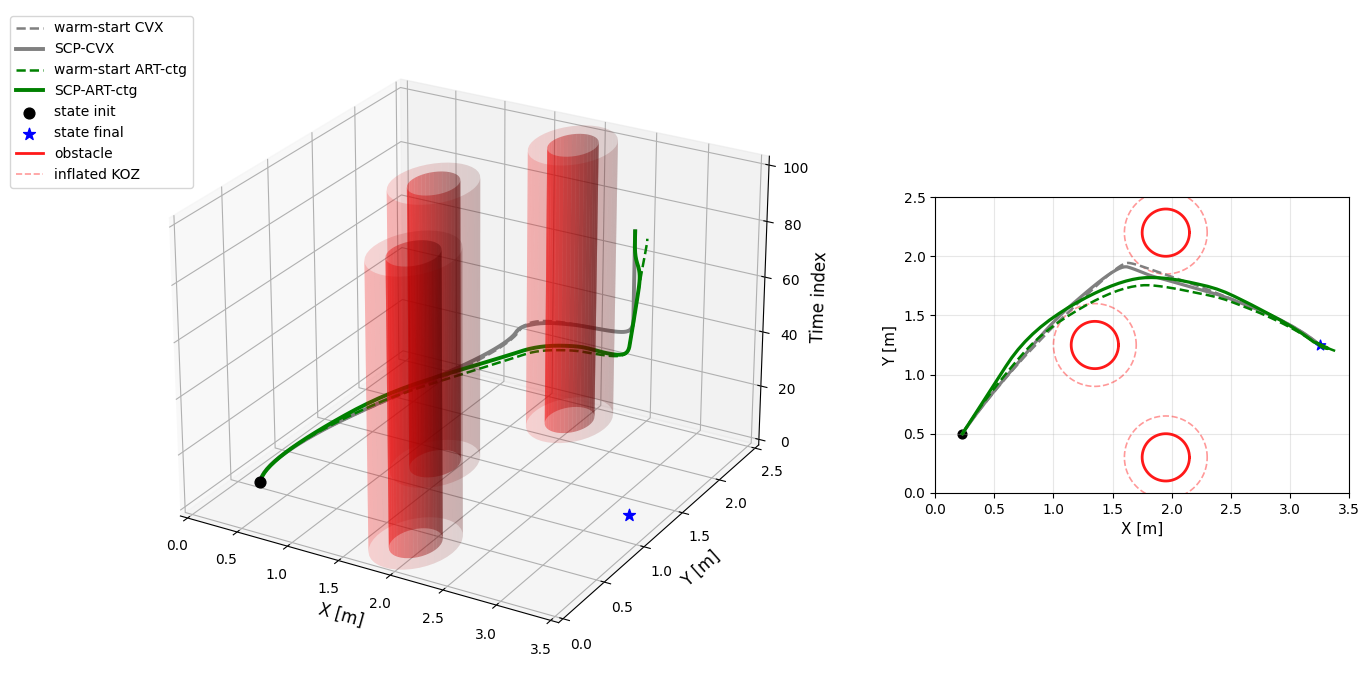

In [33]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

# ------------------------------
# Time vectors
# ------------------------------
T_ws_cvx   = states_ws_cvx.shape[1]
T_scp_cvx  = states_scp_full.shape[1]
T_ws_ctg   = states_ws_DT_ctg.shape[1]
T_scp_ctg  = states_scp_DT_ctg.shape[1]

t_ws_cvx   = np.arange(T_ws_cvx)
t_scp_cvx  = np.arange(T_scp_cvx)
t_ws_ctg   = np.arange(T_ws_ctg)
t_scp_ctg  = np.arange(T_scp_ctg)

T_max = max(T_ws_cvx, T_scp_cvx, T_ws_ctg, T_scp_ctg)

# Helper: extract X,Y
def xy(state):
    return state[0, :], state[1, :]

x_ws_cvx,  y_ws_cvx  = xy(states_ws_cvx)
x_scp_cvx, y_scp_cvx = xy(states_scp_full)
x_ws_ctg,  y_ws_ctg  = xy(states_ws_DT_ctg)
x_scp_ctg, y_scp_ctg = xy(states_scp_DT_ctg)

# --------------------------------------------------
# Figure with 3D main panel + 2D XY projection panel
# --------------------------------------------------
fig = plt.figure(figsize=(14, 7))
gs  = GridSpec(1, 2, width_ratios=[2.3, 1.0], figure=fig)

ax = fig.add_subplot(gs[0, 0], projection='3d')   # main 3D
ax_xy = fig.add_subplot(gs[0, 1])                 # XY projection

# ==========================
# 3D PANEL: (X, Y, Time)
# ==========================

# CVX warm-start
ax.plot(
    x_ws_cvx, y_ws_cvx, t_ws_cvx,
    '--', color='grey', linewidth=1.8,
    label='warm-start CVX'
)

# CVX SCP
ax.plot(
    x_scp_cvx, y_scp_cvx, t_scp_cvx,
    '-', color='grey', linewidth=2.8,
    label='SCP-CVX'
)

# ART warm-start
ax.plot(
    x_ws_ctg, y_ws_ctg, t_ws_ctg,
    '--', color='green', linewidth=1.8,
    label='warm-start ART-ctg'
)

# ART SCP
ax.plot(
    x_scp_ctg, y_scp_ctg, t_scp_ctg,
    '-', color='green', linewidth=2.8,
    label='SCP-ART-ctg'
)

# Obstacles as cylinders (extruded along Z=time)
n_theta = 40
n_t = 2

theta = np.linspace(0, 2*np.pi, n_theta)
tau   = np.linspace(0, T_max, n_t)
Theta, Tau = np.meshgrid(theta, tau)

for i in range(obs['radius'].shape[0]):
    x0, y0 = obs['position'][i]
    r_main = obs['radius'][i]
    r_inf  = obs['radius'][i] + robot_radius

    # main obstacle cylinder
    X_main = x0 + r_main * np.cos(Theta)
    Y_main = y0 + r_main * np.sin(Theta)
    Z_main = Tau

    ax.plot_surface(
        X_main, Y_main, Z_main,
        color='red', alpha=0.40, linewidth=0
    )

    # inflated (robot radius safety) cylinder
    X_inf = x0 + r_inf * np.cos(Theta)
    Y_inf = y0 + r_inf * np.sin(Theta)
    Z_inf = Tau

    ax.plot_surface(
        X_inf, Y_inf, Z_inf,
        color='red', alpha=0.15, linewidth=0
    )

# Start & Goal at time=0
ax.scatter(
    state_init[0], state_init[1], 0,
    s=60, c='black', label='state init'
)
ax.scatter(
    state_final[0], state_final[1], 0,
    s=80, c='blue', marker='*', label='state final'
)

# Axes Formatting (3D)
ax.set_xlabel("X [m]", fontsize=12)
ax.set_ylabel("Y [m]", fontsize=12)
ax.set_zlabel("Time index", fontsize=12)

ax.set_xlim(0, table['xy_up'][0])
ax.set_ylim(0, table['xy_up'][1])
ax.set_zlim(0, T_max)

ax.view_init(elev=25, azim=-60)
ax.grid(True, alpha=0.3)

# ==========================
# 2D PANEL: XY PROJECTION
# ==========================

# Obstacles as circles (main + inflated)
th = np.linspace(0, 2*np.pi, 200)
for i in range(obs['radius'].shape[0]):
    x0, y0 = obs['position'][i]
    r_main = obs['radius'][i]
    r_inf  = obs['radius'][i] + robot_radius

    ax_xy.plot(
        x0 + r_main*np.cos(th),
        y0 + r_main*np.sin(th),
        color='red', linewidth=2, alpha=0.9, label='obstacle' if i == 0 else None
    )
    ax_xy.plot(
        x0 + r_inf*np.cos(th),
        y0 + r_inf*np.sin(th),
        color='red', linewidth=1.2, alpha=0.4, linestyle='--',
        label='inflated KOZ' if i == 0 else None
    )

# Trajectories in XY
ax_xy.plot(x_ws_cvx,  y_ws_cvx,  '--', color='grey',  linewidth=1.8, label='warm-start CVX')
ax_xy.plot(x_scp_cvx, y_scp_cvx, '-',  color='grey',  linewidth=2.3, label='SCP-CVX')
ax_xy.plot(x_ws_ctg,  y_ws_ctg,  '--', color='green', linewidth=1.8, label='warm-start ART-ctg')
ax_xy.plot(x_scp_ctg, y_scp_ctg, '-',  color='green', linewidth=2.3, label='SCP-ART-ctg')

# Start & Goal
ax_xy.scatter(state_init[0],  state_init[1],  s=40, c='black', label='state init')
ax_xy.scatter(state_final[0], state_final[1], s=60, c='blue', marker='*', label='state final')

ax_xy.set_xlabel("X [m]", fontsize=11)
ax_xy.set_ylabel("Y [m]", fontsize=11)
ax_xy.set_xlim(0, table['xy_up'][0])
ax_xy.set_ylim(0, table['xy_up'][1])
ax_xy.set_aspect('equal', adjustable='box')
ax_xy.grid(True, alpha=0.3)

# ------------------------------
# Legend (shared)
# ------------------------------
# Combine handles from both axes and put one legend
handles, labels = [], []
for a in (ax, ax_xy):
    h, l = a.get_legend_handles_labels()
    handles += h
    labels  += l

# drop duplicates while preserving order
seen = set()
handles_unique, labels_unique = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        handles_unique.append(h)
        labels_unique.append(l)
        seen.add(l)

fig.legend(handles_unique, labels_unique, loc='upper left', bbox_to_anchor=(0.02, 0.98))

plt.tight_layout()
plt.show()
